# 01 — Data quality and experiment overview

**Purpose.** Establish what the Hillstrom dataset contains, confirm it is fit for
causal analysis, and fix the data contracts that the rest of the project depends on.

This notebook is exploratory. Everything it establishes is promoted to
`src/data/load.py` and enforced by `tests/test_data.py`, so the pipeline never
relies on a check that only ever ran here once.

In [1]:
import sys
from pathlib import Path

# The notebook runs from notebooks/; put the project root on the path.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src import config
from src.data.load import load_raw, validate, add_derived_columns

pd.set_option("display.width", 100)

raw = load_raw()
raw.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 1. Structure and completeness

The first question for any experimental dataset: is anything missing, and is it
missing *differentially* between arms? Differential missingness would break the
comparability that randomisation buys.

In [2]:
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Total missing values: {raw.isna().sum().sum()}")
print(f"Fully duplicated rows: {raw.duplicated().sum():,}")
print()
raw.dtypes.to_frame("dtype")

Shape: 64,000 rows x 12 columns
Total missing values: 0
Fully duplicated rows: 6,562



,dtype
recency,int64
history_segment,str
history,float64
mens,int64
womens,int64
zip_code,str
newbie,int64
channel,str
segment,str
visit,int64


**No missing values at all**, so differential missingness is not a concern here.

### On the 6,562 duplicate rows

They are **kept**. The dataset carries no customer identifier, and the feature space
is coarse — 8 attributes, most of them low-cardinality — so distinct customers can
legitimately produce an identical row.

The decisive argument is not that duplicates *might* be legitimate, it is what
dropping them would do: rows are duplicated precisely when a customer has a *common*
attribute profile, so de-duplicating would non-randomly delete the most typical
customers. That breaks the randomisation the entire analysis rests on. Keeping a few
possible true duplicates is the far smaller error.

In [3]:
# Duplication is a property of common attribute profiles, not of one arm.
dupe_rate_by_arm = (
    raw.assign(is_dupe=raw.duplicated(keep=False))
       .groupby("segment", observed=True)["is_dupe"]
       .mean()
       .rename("share of rows that are non-unique")
)
dupe_rate_by_arm.to_frame().style.format("{:.3%}")

,share of rows that are non-unique
segment,
Mens E-Mail,11.752%
No E-Mail,11.992%
Womens E-Mail,12.040%


The duplicate rate is essentially identical across arms, which is what we would
expect if duplication reflects attribute commonality rather than a data fault
affecting one arm.

## 2. Randomisation: how many customers per arm?

In [4]:
arm_counts = raw["segment"].value_counts().sort_index()
arm_summary = pd.DataFrame({
    "customers": arm_counts,
    "share": arm_counts / len(raw),
})
arm_summary.style.format({"customers": "{:,}", "share": "{:.3%}"})

,customers,share
segment,,
Mens E-Mail,"21,307",33.292%
No E-Mail,"21,306",33.291%
Womens E-Mail,"21,387",33.417%


Close to an equal three-way split. Whether the small deviation is consistent with
chance is a formal question — the sample ratio mismatch test in Feature 3 answers it
rather than eyeballing it here.

## 3. Outcomes by arm

In [5]:
outcomes = (
    raw.groupby("segment", observed=True)
       .agg(customers=("visit", "size"),
            visit_rate=("visit", "mean"),
            conversion_rate=("conversion", "mean"),
            mean_spend=("spend", "mean"))
       .sort_index()
)
outcomes.style.format({
    "customers": "{:,}",
    "visit_rate": "{:.2%}",
    "conversion_rate": "{:.3%}",
    "mean_spend": "${:.3f}",
})

,customers,visit_rate,conversion_rate,mean_spend
segment,,,,
Mens E-Mail,"21,307",18.28%,1.253%,$1.423
No E-Mail,"21,306",10.62%,0.573%,$0.653
Womens E-Mail,"21,387",15.14%,0.884%,$1.077


Both email arms sit above control on all three outcomes. Whether those gaps are
statistically real, and how much of the apparent spend gap is noise from a highly
skewed outcome, is Feature 4's job — nothing is being claimed yet.

The three outcomes live on completely different scales (≈15%, ≈1%, ≈$1), so they are
plotted as **small multiples with independent axes** rather than forced onto one
pair of axes.

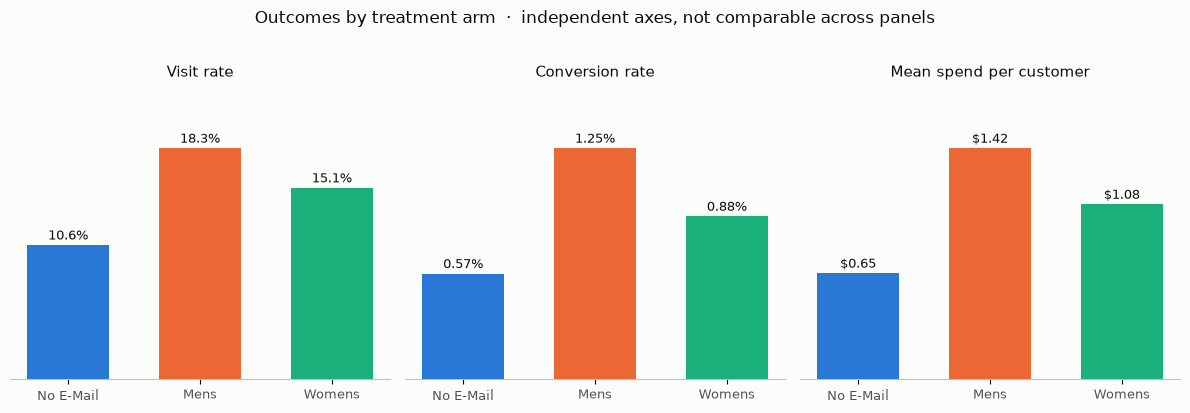

In [6]:
# Categorical palette, slots 1-3. Colour follows the arm, held fixed across panels.
ARM_COLOURS = {
    "No E-Mail": "#2a78d6",
    "Mens E-Mail": "#eb6834",
    "Womens E-Mail": "#1baf7a",
}
ARM_ORDER = list(ARM_COLOURS)

panels = [
    ("visit", "Visit rate", "{:.1%}", lambda v: v),
    ("conversion", "Conversion rate", "{:.2%}", lambda v: v),
    ("spend", "Mean spend per customer", "${:.2f}", lambda v: v),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor("#fcfcfb")

for ax, (col, title, fmt, _) in zip(axes, panels):
    ax.set_facecolor("#fcfcfb")
    values = [raw.loc[raw.segment == arm, col].mean() for arm in ARM_ORDER]
    bars = ax.bar(
        range(len(ARM_ORDER)), values,
        width=0.62,                      # leaves a clear gap between bars
        color=[ARM_COLOURS[a] for a in ARM_ORDER],
        zorder=3,
    )
    # Direct labels on every bar: three of the palette slots fall below 3:1
    # contrast on a light surface, so the values must be readable without colour.
    for bar, value in zip(bars, values):
        ax.annotate(fmt.format(value),
                    (bar.get_x() + bar.get_width() / 2, value),
                    textcoords="offset points", xytext=(0, 4),
                    ha="center", fontsize=9, color="#0b0b0b")

    ax.set_title(title, fontsize=11, color="#0b0b0b", pad=10)
    ax.set_xticks(range(len(ARM_ORDER)))
    ax.set_xticklabels(["No E-Mail", "Mens", "Womens"], fontsize=9, color="#52514e")
    ax.set_ylim(0, max(values) * 1.25)
    ax.yaxis.set_visible(False)
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.8, zorder=0)   # recessive grid
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")

fig.suptitle("Outcomes by treatment arm  ·  independent axes, not comparable across panels",
             fontsize=12, color="#0b0b0b", y=1.02)
fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "01_outcomes_by_arm.png", dpi=150, bbox_inches="tight",
            facecolor="#fcfcfb")
plt.show()

## 4. The outcome hierarchy

Three outcomes are recorded, and they are not independent. Checking how they nest
tells us which statistical model is appropriate for each.

In [7]:
checks = {
    "converted without visiting": ((raw.conversion == 1) & (raw.visit == 0)).sum(),
    "spend recorded without converting": ((raw.spend > 0) & (raw.conversion == 0)).sum(),
    "converted but zero spend": ((raw.conversion == 1) & (raw.spend <= 0)).sum(),
    "negative spend": (raw.spend < 0).sum(),
}
pd.Series(checks, name="violations").to_frame()

,violations
converted without visiting,0
spend recorded without converting,0
converted but zero spend,0
negative spend,0


**Zero violations on all four.** So the outcomes form a strict funnel:

```
visit = 1  ⊃  conversion = 1  ⟺  spend > 0
```

Two consequences the later features depend on:

1. `spend` is **zero-inflated**: 99.1% of customers spend exactly $0. Its mean is
   therefore dominated by a few hundred purchasers, and a naive t-test on it will be
   badly underpowered. This is why Feature 4 pairs the t-test with a bootstrap
   interval and Feature 5 computes what sample size the spend outcome would actually
   need.
2. Because these invariants hold *exactly*, they become enforced contracts rather
   than observations — if a future data refresh breaks the funnel, the pipeline
   fails loudly instead of producing a silently inconsistent model.

In [8]:
spend_zero_share = (raw.spend == 0).mean()
purchasers = raw.loc[raw.spend > 0, "spend"]

print(f"Customers spending $0:            {spend_zero_share:.2%}")
print(f"Purchasers:                       {len(purchasers):,}")
print(f"Mean spend | purchased:           ${purchasers.mean():.2f}")
print(f"Mean spend | all customers:       ${raw.spend.mean():.3f}")
print(f"Std dev of spend (all customers): ${raw.spend.std():.2f}  <- ~14x the mean")

Customers spending $0:            99.10%
Purchasers:                       578
Mean spend | purchased:           $116.36
Mean spend | all customers:       $1.051
Std dev of spend (all customers): $15.04  <- ~14x the mean


## 5. Pre-treatment covariates

These describe the customer *before* the send, so they are safe to use for balance
checks (Feature 3), CUPED adjustment (Feature 6) and uplift features (Feature 8)
without inducing post-treatment bias.

In [9]:
raw[["recency", "history"]].describe().T.style.format("{:,.2f}")

,count,mean,std,min,25%,50%,75%,max
recency,"64,000.00",5.76,3.51,1.00,2.00,6.00,9.00,12.00
history,"64,000.00",242.09,256.16,29.99,64.66,158.11,325.66,"3,345.93"


In [10]:
for col in ["history_segment", "zip_code", "channel"]:
    counts = raw[col].value_counts().sort_index()
    print(f"--- {col} ---")
    print((counts / len(raw)).map("{:.1%}".format).to_string())
    print()

--- history_segment ---
history_segment
1) $0 - $100        35.9%
2) $100 - $200      22.3%
3) $200 - $350      19.2%
4) $350 - $500      10.0%
5) $500 - $750       7.7%
6) $750 - $1,000     2.9%
7) $1,000 +          2.0%

--- zip_code ---
zip_code
Rural        14.9%
Surburban    45.0%
Urban        40.1%

--- channel ---
channel
Multichannel    12.1%
Phone           43.8%
Web             44.1%



`history` (prior spend) is heavily right-skewed — mean \$242 against a median of
\$158 and a maximum of \$3,346. It is the strongest available pre-period predictor of
spend, which makes it the natural **CUPED covariate** in Feature 6. The dataset has
no repeated pre-experiment measurement of the outcome itself, so prior spend is the
closest valid stand-in, and the variance reduction it delivers should be honestly
reported rather than assumed.

## 6. Promoting these findings to contracts

Everything established above is now encoded in `src/data/load.py`. Running the
validator here confirms the module agrees with the notebook.

In [11]:
validate(raw)          # raises DataContractError on any violation
print("All data contracts passed.\n")

processed = add_derived_columns(raw)
print(f"Processed: {processed.shape[0]:,} rows x {processed.shape[1]} columns")
print(f"Derived columns: {sorted(set(processed.columns) - set(raw.columns))}")
processed[["recency", "recency_bucket", "history", "log_history",
           "history_segment", "history_segment_rank"]].head()

All data contracts passed.

Processed: 64,000 rows x 15 columns
Derived columns: ['history_segment_rank', 'log_history', 'recency_bucket']


,recency,recency_bucket,history,log_history,history_segment,history_segment_rank
0,10,10-12 months,142.44,4.965917,2) $100 - $200,2
1,6,4-6 months,329.08,5.799335,3) $200 - $350,3
2,7,7-9 months,180.65,5.202082,2) $100 - $200,2
3,9,7-9 months,675.83,6.517420,5) $500 - $750,5
4,2,1-3 months,45.34,3.836006,1) $0 - $100,1


## Summary

| Question | Finding |
|---|---|
| Is the data complete? | Yes — 64,000 rows, zero missing values |
| Are the arms balanced in size? | Near-equal three-way split; formally tested in Feature 3 |
| Do the duplicates need removing? | No — removing them would non-randomly drop typical customers |
| Do the outcomes nest? | Yes, exactly: `visit ⊃ conversion ⟺ spend > 0` |
| What will be hard? | `spend` is 99.1% zeros with a std dev ~14x its mean |
| What is the CUPED covariate? | `history`, the only strong pre-period predictor available |

**Next — Feature 2:** load this into DuckDB and build the SQL metric views the
dashboard will read.